<a href="https://colab.research.google.com/github/gretazehnder/apriori-market-basket-analysis/blob/main/mba_apriori_fromscratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market basket analysis - IMDB Dataset

Movies are modeled as transactions (baskets) and actors as items.
The goal is to discover frequent co-acting patterns using a custom Apriori implementation.

## Environment setup

In [ ]:
!pip -q install kaggle

In [ ]:
import os
import time
import random
import pandas as pd
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt

## Dataset download

In [ ]:
os.environ['KAGGLE_USERNAME'] = 'x'
os.environ['KAGGLE_KEY'] = 'x'
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
!unzip -q "*.zip"

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)
replace imdb_top_1000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Data loading

In [ ]:
df = pd.read_csv('imdb_top_1000.csv')
print(df.shape)
df.head()

(1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Preprocessing

We select only the actor columns and convert each movie into a transaction (a list of actors).

In [ ]:
df = df[['Star1', 'Star2', 'Star3', 'Star4']].dropna()
print(df.shape)

transactions = df.values.tolist()
print(f'Number of transactions: {len(transactions)}')
print('Example:', transactions[:3])

(1000, 4)
Number of transactions: 1000
Example: [['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler'], ['Marlon Brando', 'Al Pacino', 'James Caan', 'Diane Keaton'], ['Christian Bale', 'Heath Ledger', 'Aaron Eckhart', 'Michael Caine']]


## Exploratory analysis and support threshold selection

Before running Apriori, we analyze the frequency distribution of actors to choose an appropriate
minimum support threshold. Filtering infrequent actors reduces the number of distinct items,
which lowers memory usage and speeds up mining.

In [ ]:
item_counts = Counter()
for basket in transactions:
    item_counts.update(basket)

print(f'Distinct actors: {len(item_counts)}')
print('Top 10:', item_counts.most_common(10))

Distinct actors: 2709
Top 10: [('Robert De Niro', 17), ('Tom Hanks', 14), ('Al Pacino', 13), ('Brad Pitt', 12), ('Clint Eastwood', 12), ('Christian Bale', 11), ('Leonardo DiCaprio', 11), ('Matt Damon', 11), ('James Stewart', 10), ('Michael Caine', 9)]


In [ ]:
# try min_support = 1% --> at least 10 appearances out of 1000 movies
min_support = 0.01
min_count = int(min_support * len(transactions))  # 10

allowed = {item for item, c in item_counts.items() if c >= min_count}
print(f'min_support=1%  --> min_count={min_count}, actors remaining: {len(allowed)}')

min_support=1%  --> min_count=10, actors remaining: 9


In [ ]:
# 1% is too restrictive (only 9 actors) --> lower to 0.5% --> at least 5 appearances out of 1000 movies
min_support = 0.005
min_count_filter = int(min_support * len(transactions))  # 5

allowed = {item for item, c in item_counts.items() if c >= min_count_filter}

transactions_filtered = [
    [item for item in basket if item in allowed]
    for basket in transactions
]
transactions_filtered = [t for t in transactions_filtered if t]

# min_count for Apriori: same threshold used to filter actors (computed on the original 1000 movies)
# this keeps the definition of "frequent" consistent throughout the pipeline
min_count = min_count_filter  # 5

print(f'min_support=0.5% --> filter threshold={min_count_filter}, actors remaining: {len(allowed)}')
print(f'Baskets remaining: {len(transactions_filtered)}')
print(f'min_count for Apriori: {min_count}')

min_support=0.5% --> filter threshold=5, actors remaining: 79
Baskets remaining: 399
min_count for Apriori: 5


## Apriori implementation

Apriori is based on the antimonotonicity property: if an itemset is infrequent, all its supersets are infrequent too.
This allows pruning candidates without scanning all combinations.

The algorithm works in passes:
1. Count all single items, keep frequent ones (L1)
2. Generate candidate pairs from L1, count them, keep frequent ones (L2)
3. Generate candidate triples from L2, count them, keep frequent ones (L3)
4. Stop when no new frequent itemsets are found

In [ ]:
def count_singletons(baskets):
    #count how many baskets each item appears in
    counts = Counter()
    for basket in baskets:
        counts.update(basket)  # adds 1 for each item in the basket
    return counts

In [ ]:
def generate_candidates(prev_frequent, k):
    # generate candidate k-itemsets from frequent (k-1)-itemsets, with antimonotonicity pruning

    prev_set = set(prev_frequent)  # for fast lookup
    candidates = set()

    prev_list = sorted(prev_frequent)
    n = len(prev_list)

    for i in range(n):
        for j in range(i + 1, n):
            # merge two (k-1)-itemsets into a k-itemset
            candidate = tuple(sorted(set(prev_list[i]) | set(prev_list[j])))
            if len(candidate) != k:
                continue

            # pruning
            valid = all(
                tuple(sorted(subset)) in prev_set
                for subset in combinations(candidate, k - 1)
            )
            if valid:
                candidates.add(candidate)

    return candidates

In [ ]:
def count_candidates(baskets, candidates, frequent_items, k):

    candidate_set = set(candidates)
    counts = Counter()

    for basket in baskets:
        # keep only frequent items in this basket
        eligible = sorted(item for item in basket if item in frequent_items)
        if len(eligible) < k:
            continue

        for combo in combinations(eligible, k):
            if combo in candidate_set:
                counts[combo] += 1

    return counts

In [ ]:
def apriori(baskets, min_count):
  # run Apriori up to 3-itemsets
    all_frequent = {}

    # frequent singletons
    singleton_counts = count_singletons(baskets)
    L1 = {
        (item,): count
        for item, count in singleton_counts.items()
        if count >= min_count
    }
    all_frequent[1] = L1
    frequent_items = {item for (item,) in L1}  # flat set of frequent actors
    prev_frequent = list(L1.keys())


    for k in range(2, 4):
        candidates = generate_candidates(prev_frequent, k)

        if not candidates:
            all_frequent[k] = {}
            break

        counts = count_candidates(baskets, candidates, frequent_items, k)

        Lk = {
            itemset: count
            for itemset, count in counts.items()
            if count >= min_count
        }
        Lk = dict(sorted(Lk.items(), key=lambda x: -x[1]))
        all_frequent[k] = Lk
        prev_frequent = list(Lk.keys())

    return all_frequent

## Run Apriori

In [ ]:
frequent_itemsets = apriori(transactions_filtered, min_count)

print(f'min_count={min_count}, baskets={len(transactions_filtered)}')
for k in sorted(frequent_itemsets):
    print(f'Frequent {k}-itemsets: {len(frequent_itemsets[k])}')

min_count=5, baskets=399
Frequent 1-itemsets: 79
Frequent 2-itemsets: 3
Frequent 3-itemsets: 1


## Results

In [ ]:
n = len(transactions_filtered)

for k in sorted(frequent_itemsets.keys()):
    items = frequent_itemsets[k]
    print(f'\n--- Frequent {k}-itemsets ({len(items)} total) ---')
    for itemset, count in items.items():
        print(f'  {itemset}  count={count}  support={count/n:.4f}')


--- Frequent 1-itemsets (79 total) ---
  ('Morgan Freeman',)  count=7  support=0.0175
  ('Al Pacino',)  count=13  support=0.0326
  ('Diane Keaton',)  count=6  support=0.0150
  ('Christian Bale',)  count=11  support=0.0276
  ('Michael Caine',)  count=9  support=0.0226
  ('Robert De Niro',)  count=17  support=0.0426
  ('Viggo Mortensen',)  count=5  support=0.0125
  ('Ian McKellen',)  count=7  support=0.0175
  ('Samuel L. Jackson',)  count=6  support=0.0150
  ('Bruce Willis',)  count=7  support=0.0175
  ('Leonardo DiCaprio',)  count=11  support=0.0276
  ('Brad Pitt',)  count=12  support=0.0301
  ('Edward Norton',)  count=7  support=0.0175
  ('Tom Hanks',)  count=14  support=0.0351
  ('Clint Eastwood',)  count=12  support=0.0301
  ('Joe Pesci',)  count=6  support=0.0150
  ('Harrison Ford',)  count=8  support=0.0201
  ('Jack Nicholson',)  count=6  support=0.0150
  ('Matthew McConaughey',)  count=6  support=0.0150
  ('Matt Damon',)  count=11  support=0.0276
  ('Kevin Spacey',)  count=5  sup

The most frequent co-acting pair is (Daniel Radcliffe, Rupert Grint), reflecting their repeated
collaboration in the Harry Potter series. The top three pairs all involve Harry Potter cast members.

## Scalability experiment

To evaluate how Apriori scales with dataset size, we sample increasing fractions of the filtered
transactions (30%, 60%, 100%) and measure the average runtime over 10 runs.
Averaging over multiple runs reduces the effect of random fluctuations in execution time.
The minimum count threshold is kept fixed at 5 across all fractions.

In [ ]:
fractions = [0.3, 0.6, 1.0]
num_runs = 10
bench = []

total = len(transactions_filtered)

for frac in fractions:
    random.seed(42)
    num_samples = int(total * frac)
    sub = random.sample(transactions_filtered, num_samples)

    total_time = 0
    for _ in range(num_runs):
        t0 = time.perf_counter()
        apriori(sub, min_count)
        total_time += time.perf_counter() - t0

    avg_time = total_time / num_runs
    bench.append({
        'fraction': frac,
        'baskets': num_samples,
        'avg_time_sec': round(avg_time, 4)
    })
    print(f'fraction={frac}  baskets={num_samples}  avg_time={avg_time:.4f}s')

bench_df = pd.DataFrame(bench)
bench_df

fraction=0.3  baskets=119  avg_time=0.0002s
fraction=0.6  baskets=239  avg_time=0.0011s
fraction=1.0  baskets=399  avg_time=0.0074s


,fraction,baskets,avg_time_sec
0,0.3,119,0.0002
1,0.6,239,0.0011
2,1.0,399,0.0074


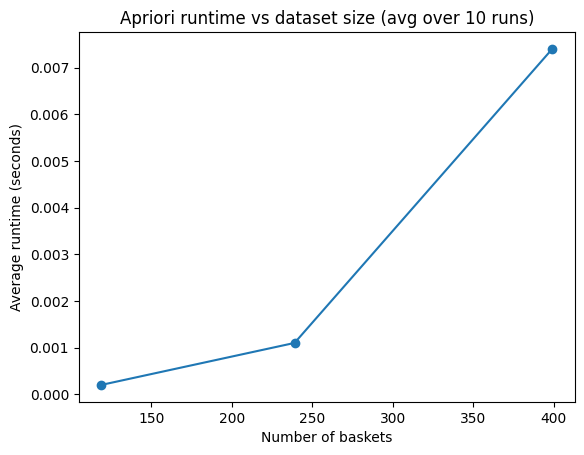

In [ ]:
plt.figure()
plt.plot(bench_df['baskets'], bench_df['avg_time_sec'], marker='o')
plt.xlabel('Number of baskets')
plt.ylabel('Average runtime (seconds)')
plt.title(f'Apriori runtime vs dataset size (avg over {num_runs} runs)')
plt.show()

## Conclusion

Movies were modeled as transactions and actors as items to discover frequent co-acting patterns.
After preprocessing and support-based filtering (threshold: 0.5%), the dataset was reduced to
399 baskets and 79 distinct actors.

Apriori identified frequent itemsets up to size 3. The most frequent co-acting pair is
(Daniel Radcliffe, Rupert Grint), reflecting their repeated collaboration in the Harry Potter series.

The scalability experiment showed that runtime grows approximately linearly with the number of
baskets, consistent with the O(n) scan per pass of the algorithm.